# Home Run Hitting

## 13.1 Introduction

This chapter investigates what drives home run hitting using Statcast data from 2021 and 2023, covering launch variables, spray angle, ballpark effects, and a season-to-season comparison.

## 13.2 Exploring a Season of Home Run Hitting

### 13.2.1 Meet Data

Statcast data for the full 2021 and 2023 regular seasons, filtered to balls in play (`type == 'X'`).

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pybaseball import statcast

def gg_style(ax):
    """Apply ggplot styling to plot"""
    ax.set_facecolor('#EBEBEB')
    ax.figure.patch.set_facecolor('white')
    ax.grid(color='white', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_visible(False)

sc_2021_raw = statcast(start_dt='2021-04-01', end_dt='2021-10-03')
sc_2023_raw = statcast(start_dt='2023-03-30', end_dt='2023-10-01')

This is a large query, it may take a moment to complete


100%|██████████| 186/186 [00:59<00:00,  3.12it/s]


This is a large query, it may take a moment to complete


100%|██████████| 186/186 [01:00<00:00,  3.07it/s]


In [25]:
sc_two_seasons = pd.concat([
    sc_2021_raw.assign(Season=2021),
    sc_2023_raw.assign(Season=2023)
])
sc_bip = sc_two_seasons[sc_two_seasons['type'] == 'X'].copy()
sc_bip['HR'] = (sc_bip['events'] == 'home_run').astype(int)

sc_2023 = sc_bip[sc_bip['Season'] == 2023].copy()
sc_2021 = sc_bip[sc_bip['Season'] == 2021].copy()

sc_2023_orig = sc_2023.copy()
sc_2021_orig = sc_2021.copy()

bip = len(sc_2023)
hr = sc_2023['HR'].sum()
hr_rate = 100 * hr / bip

pd.DataFrame({'BIP': [bip], 'HR': [hr], 'HR_Rate': [round(hr_rate, 2)]})

,BIP,HR,HR_Rate
0,124234,5868,4.72


The 2023 season had 124,234 balls in play, 5,868 home runs, and a HR rate of 4.72%.

### 13.2.2 Home Runs and Launch Variables

Fit a GAM with a 2D tensor smooth of launch angle and launch speed to estimate HR probability across the full range of batted ball outcomes.

In [26]:
from pygam import LogisticGAM, te

sc_2023_clean = sc_2023.dropna(subset=['launch_angle', 'launch_speed']).copy()
X = sc_2023_clean[['launch_angle', 'launch_speed']].values
y = sc_2023_clean['HR'].values

gam = LogisticGAM(te(0, 1, n_splines=20, lam=0.01)).fit(X, y)

In [27]:
prob_105_25 = gam.predict_proba(np.array([[25, 105]]))[0]
print(f'P(HR | launch_angle=25 deg, launch_speed=105 mph) = {prob_105_25:.3f}')

P(HR | launch_angle=25 deg, launch_speed=105 mph) = 0.771


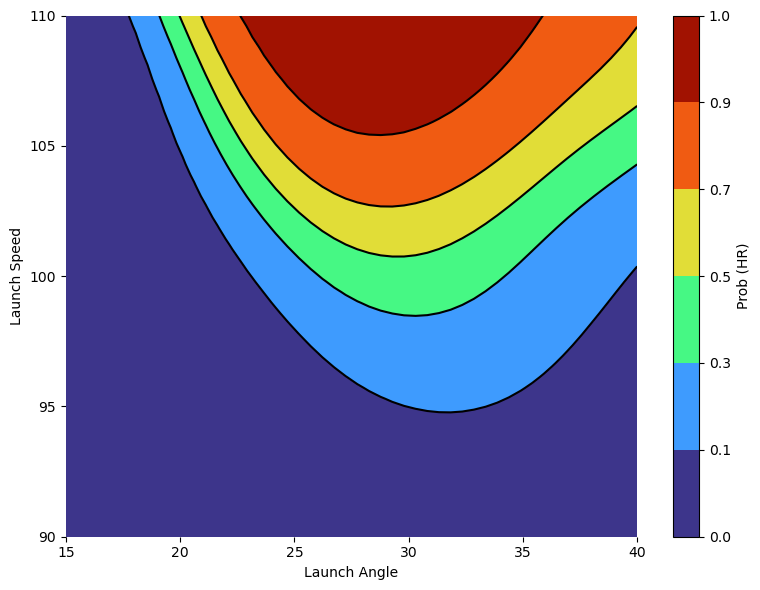

In [28]:
la_range = np.linspace(15, 40, 50)
ls_range = np.linspace(90, 110, 50)
LA, LS = np.meshgrid(la_range, ls_range)
grid = np.column_stack([LA.ravel(), LS.ravel()])
probs = gam.predict_proba(grid).reshape(LS.shape)

levels = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
fig, ax = plt.subplots(figsize=(8, 6))
gg_style(ax)
cs = ax.contourf(LA, LS, probs, levels=levels, cmap='turbo', zorder=2)
ax.contour(LA, LS, probs, levels=levels, colors='black', linewidths=1.5, zorder=3)
cbar = plt.colorbar(cs, ax=ax)
cbar.set_label('Prob (HR)')
cbar.set_ticks(levels)
ax.set_xlabel('Launch Angle')
ax.set_ylabel('Launch Speed')
ax.set_yticks([90, 95, 100, 105, 110])
plt.tight_layout()
plt.show()

At 105 mph and 25°, the model predicts a 77% HR probability. Launch angle must also be in the 20 to 35° sweet spot, and balls hit at 90 mph have near zero probability regardless of angle.

### 13.2.3 What is the optimal launch angle?

Optimal launch angle: 29.3 degrees


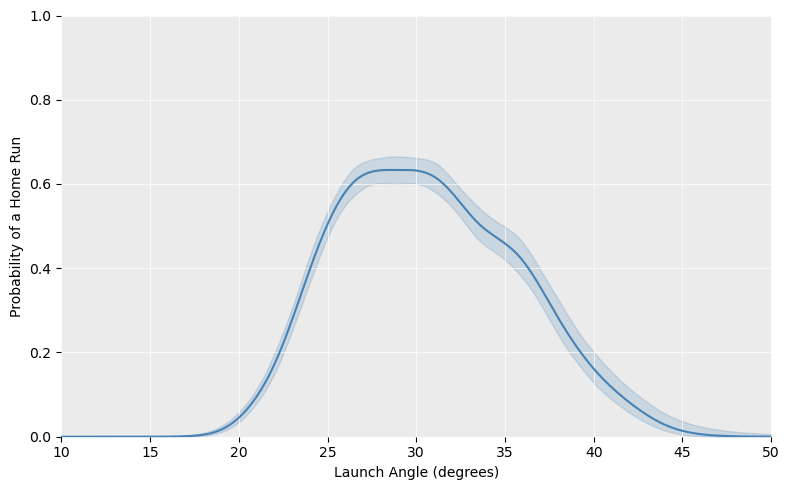

In [29]:
from pygam import s

hard_hit = sc_2023_clean[
    (sc_2023_clean['launch_speed'] >= 100) &
    (sc_2023_clean['launch_speed'] <= 105) &
    (sc_2023_clean['launch_angle'] >= 10) &
    (sc_2023_clean['launch_angle'] <= 50)
].copy()

gam_la = LogisticGAM(s(0)).fit(
    hard_hit[['launch_angle']].values,
    hard_hit['HR'].values
)

la_grid = np.linspace(10, 50, 200)
probs_la = gam_la.predict_proba(la_grid.reshape(-1, 1))
peak_angle = la_grid[np.argmax(probs_la)]
print(f'Optimal launch angle: {peak_angle:.1f} degrees')

ci = gam_la.confidence_intervals(la_grid.reshape(-1, 1), width=0.95)

fig, ax = plt.subplots(figsize=(8, 5))
gg_style(ax)
ax.plot(la_grid, probs_la, color='steelblue', linewidth=1.5)
ax.fill_between(la_grid, ci[:, 0], ci[:, 1], alpha=0.2, color='steelblue')
ax.set_xlabel('Launch Angle (degrees)')
ax.set_ylabel('Probability of a Home Run')
ax.set_xlim(10, 50)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

For hard-hit balls (100 to 105 mph), HR probability peaks around 29°. Below 20° or above 40° it drops sharply. Too flat produces grounders, too steep produces pop ups.

### 13.2.4 Temperature Effects

In [30]:
temps_2023 = pd.read_csv('../data/temps_2023.csv')
parks_2023 = pd.read_csv('../data/parks_2023.csv')

temps_parks_2023 = temps_2023.merge(parks_2023, on='Park')
sc_temp_2023 = sc_2023.merge(temps_parks_2023, on='game_pk', how='inner')

temp_hr = (
    sc_temp_2023[sc_temp_2023['Dome'] == 'No']
    .groupby('temperature')
    .agg(BIP=('HR', 'count'), HR=('HR', 'sum'))
    .reset_index()
    .assign(HR_Rate=lambda d: 100 * d['HR'] / d['BIP'])
)

import statsmodels.api as sm
temp_centered = temp_hr['temperature'] - 70
X = sm.add_constant(temp_centered)
wls = sm.WLS(temp_hr['HR_Rate'], X, weights=temp_hr['BIP']).fit()
print(f'(Intercept)          I(temperature - 70)')
print(f'{wls.params.iloc[0]:.3f}                     {wls.params.iloc[1]:.3f}')

(Intercept)          I(temperature - 70)
4.652                     0.041


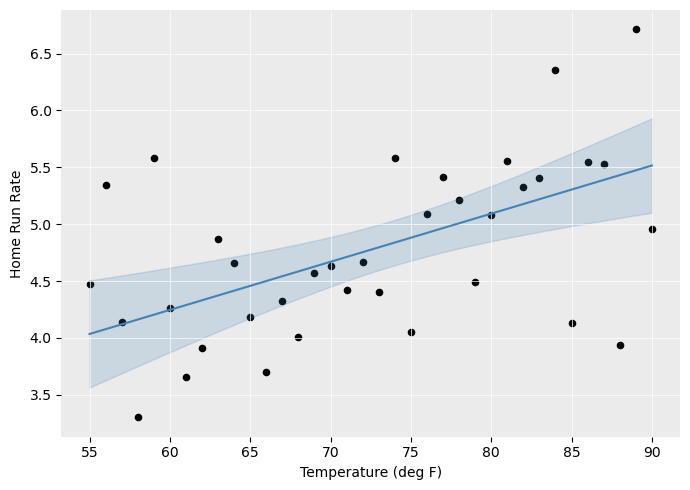

In [31]:
plot_data = temp_hr[(temp_hr['temperature'] >= 55) & (temp_hr['temperature'] <= 90)].copy()

temp_centered_plot = plot_data['temperature'] - 70
X_plot = sm.add_constant(temp_centered_plot)
wls_plot = sm.WLS(plot_data['HR_Rate'], X_plot, weights=plot_data['BIP']).fit()
x_line = np.linspace(55, 90, 200)
x_centered_line = x_line - 70
pred = wls_plot.get_prediction(sm.add_constant(pd.Series(x_centered_line)))
ci = pred.conf_int(alpha=0.05)
y_line = pred.predicted_mean

fig, ax = plt.subplots(figsize=(7, 5))
gg_style(ax)
ax.scatter(plot_data['temperature'], plot_data['HR_Rate'], color='black', s=20)
ax.plot(x_line, y_line, color='steelblue', linewidth=1.5)
ax.fill_between(x_line, ci[:, 0], ci[:, 1], alpha=0.2, color='steelblue')
ax.set_xlabel('Temperature (deg F)')
ax.set_ylabel('Home Run Rate')
plt.tight_layout()
plt.show()

Warmer temperatures are associated with higher HR rates in outdoor parks. At 70°F the baseline rate is 4.65%, rising by roughly 0.04 percentage points per additional degree.

### 13.2.5 Spray Angle Effects

Spray angle is the horizontal direction of a batted ball: 0° is straight to center, negative toward third base, positive toward first base. Compare HR distributions by batter handedness.

In [32]:
sc_2023['location_x'] = 2.5 * (sc_2023['hc_x'] - 125.42)
sc_2023['location_y'] = 2.5 * (198.27 - sc_2023['hc_y'])
sc_2023['spray_angle'] = np.degrees(
    np.arctan(sc_2023['location_x'] / sc_2023['location_y'])
)

sc_hr = sc_2023[sc_2023['events'] == 'home_run'].dropna(subset=['spray_angle'])
print(f'Home runs with spray angle: {len(sc_hr):,}')

Home runs with spray angle: 5,834


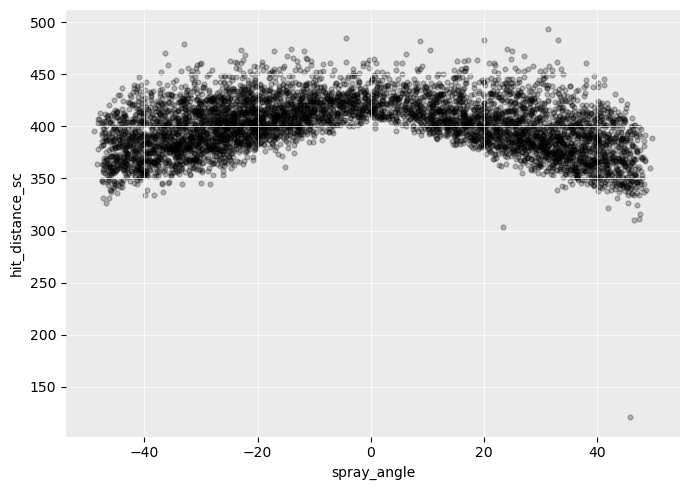

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))
gg_style(ax)
ax.scatter(sc_hr['spray_angle'], sc_hr['hit_distance_sc'], alpha=0.25, s=12, color='black')
ax.set_xlabel('spray_angle')
ax.set_ylabel('hit_distance_sc')
plt.tight_layout()
plt.show()

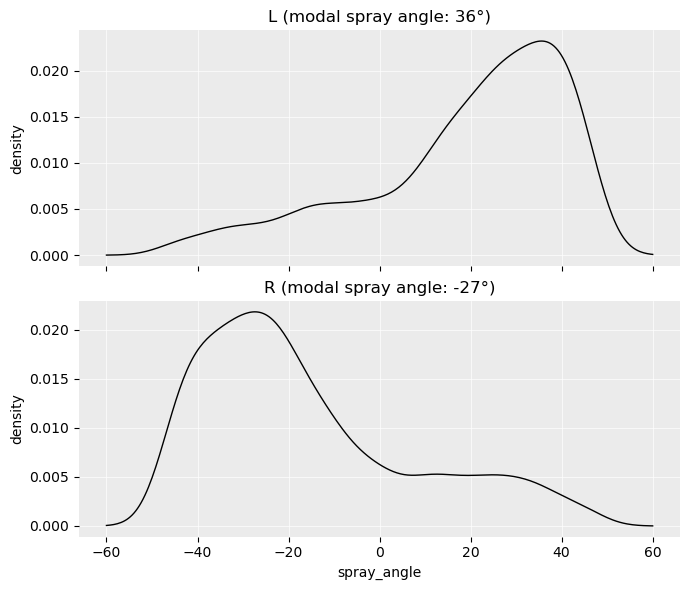

In [34]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

for ax, hand in zip(axes, ['L', 'R']):
    subset = sc_hr[sc_hr['stand'] == hand]['spray_angle'].dropna()
    kde = gaussian_kde(subset)
    x_range = np.linspace(-60, 60, 300)
    modal_angle = x_range[np.argmax(kde(x_range))]
    gg_style(ax)
    ax.plot(x_range, kde(x_range), color='black', linewidth=1)
    ax.set_ylabel('density')
    ax.set_title(f'{hand} (modal spray angle: {modal_angle:.0f}°)')

axes[-1].set_xlabel('spray_angle')
plt.tight_layout()
plt.show()

Both distributions are skewed strongly toward the pull side. Left-handed batters peak around 37° toward right field and right-handed batters peak around 25° toward left field. Very few HRs are hit to the opposite field.

### 13.2.6 Ballpark Effects

Park factor = home HRs / road HRs for each team. Values above 1 favor hitters and values below 1 favor pitchers.

In [35]:
sc_home = sc_2023.groupby('home_team')['HR'].sum().reset_index(name='HR_home')
sc_away = sc_2023.groupby('away_team')['HR'].sum().reset_index(name='HR_away')

pf = sc_home.merge(sc_away, left_on='home_team', right_on='away_team')
pf['Park_Factor'] = pf['HR_home'] / pf['HR_away']
pf = pf[['home_team', 'Park_Factor']].sort_values('home_team').reset_index(drop=True)

pf

,home_team,Park_Factor
0,ATH,0.837321
1,ATL,1.032922
2,AZ,0.770732
3,BAL,0.914894
4,BOS,0.940299
5,CHC,1.118644
6,CIN,1.372881
7,CLE,0.757396
8,COL,1.100529
9,CWS,0.984536


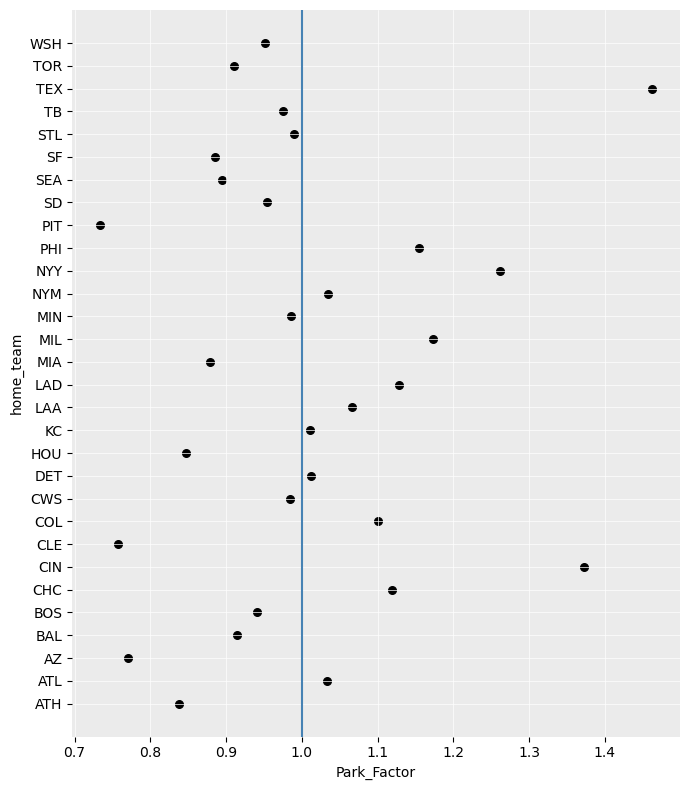

In [36]:
fig, ax = plt.subplots(figsize=(7, 8))
gg_style(ax)
ax.scatter(pf['Park_Factor'], pf['home_team'], color='black', s=30)
ax.axvline(1, color='steelblue', linewidth=1.5)
ax.set_xlabel('Park_Factor')
ax.set_ylabel('home_team')
plt.tight_layout()
plt.show()

Texas (1.46), Cincinnati (1.37), and the New York Yankees (1.26) are the most HR-friendly parks in 2023. Single-season factors are noisy, so Baseball Savant typically uses three-season averages.

### 13.2.7 Are Home Runs About the Hitter or the Pitcher?

In [37]:
batter_stats = (
    sc_2023_clean.groupby('batter')
    .agg(BIP=('HR', 'count'), HR=('HR', 'sum'))
    .reset_index()
)
batter_stats = batter_stats[batter_stats['BIP'] >= 100].copy()
batter_stats['HR_rate'] = batter_stats['HR'] / batter_stats['BIP']

pitcher_stats = (
    sc_2023_clean.groupby('pitcher')
    .agg(BIP=('HR', 'count'), HR=('HR', 'sum'))
    .reset_index()
)
pitcher_stats = pitcher_stats[pitcher_stats['BIP'] >= 100].copy()
pitcher_stats['HR_rate'] = pitcher_stats['HR'] / pitcher_stats['BIP']

print(f'Qualifying batters (100+ BIP): {len(batter_stats)}')
print(f'Qualifying pitchers (100+ BIP): {len(pitcher_stats)}')

Qualifying batters (100+ BIP): 403
Qualifying pitchers (100+ BIP): 445


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from scipy import sparse

le_batter = LabelEncoder()
le_pitcher = LabelEncoder()

batter_enc = le_batter.fit_transform(sc_2023_clean['batter'].astype(str))
pitcher_enc = le_pitcher.fit_transform(sc_2023_clean['pitcher'].astype(str))

n_b = len(le_batter.classes_)
n_p = len(le_pitcher.classes_)
n = len(batter_enc)

X_batter = sparse.csr_matrix((np.ones(n), (np.arange(n), batter_enc)), shape=(n, n_b))
X_pitcher = sparse.csr_matrix((np.ones(n), (np.arange(n), pitcher_enc)), shape=(n, n_p))
X_full = sparse.hstack([X_batter, X_pitcher])

mod = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, fit_intercept=True)
mod.fit(X_full, sc_2023_clean['HR'].values)

coef_batter = mod.coef_[0, :n_b]
coef_pitcher = mod.coef_[0, n_b:]

print(f'Groups  Name        Std.Dev.')
print(f'batter  (Intercept) {np.std(coef_batter):.3f}')
print(f'pitcher (Intercept) {np.std(coef_pitcher):.3f}')

Groups  Name        Std.Dev.
batter  (Intercept) 0.530
pitcher (Intercept) 0.378


Variation across batters (SD = 0.53) is larger than variation across pitchers (SD = 0.38), confirming that home run hitting is driven primarily by the hitter.

## 13.3 Comparing Home Run Hitting in the 2021 and 2023 Seasons

### 13.3.1 Introduction

Despite nearly identical overall HR rates, 2021 and 2023 differ in how batters are hitting and how far the ball travels. Binning launch angle and exit velocity into a grid lets us separate changes in batter behavior (BIP rate) from changes in ball carry (HR rate).

### 13.3.2 Binning Launch Variables

Bin launch angle (20 to 40°) and launch speed (95 to 110 mph) into a grid. For each bin compute the BIP rate (batter behavior) and HR rate (ball carry).

In [39]:
LA_breaks = list(range(20, 45, 5))
LS_breaks = list(range(95, 115, 5)) 

def bin_rates(sc_ip, la_breaks, ls_breaks):
    total_bip = len(sc_ip)
    df = sc_ip.copy()
    df['LS'] = pd.cut(df['launch_speed'], bins=ls_breaks)
    df['LA'] = pd.cut(df['launch_angle'], bins=la_breaks)
    result = (
        df.dropna(subset=['LA', 'LS'])
        .groupby(['LA', 'LS'], observed=False)
        .agg(BIP=('HR', 'count'), HR=('HR', 'sum'))
        .reset_index()
    )
    result['BIP_Rate'] = 100 * result['BIP'] / total_bip
    result['HR_Rate'] = 100 * result['HR'] / result['BIP'].replace(0, np.nan)
    return result

crcblue = '#215CAF'

def bin_plot(data, la_breaks, ls_breaks, label_col, label_fmt=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    gg_style(ax)

    for x in la_breaks:
        ax.axvline(x, color=crcblue, linewidth=1, zorder=2)
    for y in ls_breaks:
        ax.axhline(y, color=crcblue, linewidth=1, zorder=2)

    for _, row in data.iterrows():
        if pd.isna(row[label_col]):
            continue
        la_mid = (row['LA'].left + row['LA'].right) / 2
        ls_mid = (row['LS'].left + row['LS'].right) / 2
        val = row[label_col]
        text = label_fmt(val) if label_fmt else str(int(val)) if isinstance(val, (int, np.integer)) else str(val)
        ax.text(la_mid, ls_mid, text, ha='center', va='center', fontsize=16, zorder=3)

    ax.set_xlim(la_breaks[0], la_breaks[-1])
    ax.set_ylim(ls_breaks[0], ls_breaks[-1])
    ax.set_xticks(la_breaks)
    ax.set_yticks(ls_breaks)
    ax.set_xlabel('Launch Angle', fontsize=13)
    ax.set_ylabel('Launch Speed', fontsize=13)
    ax.tick_params(labelsize=11)
    plt.tight_layout()
    plt.show()

In [40]:
bins_2023 = bin_rates(sc_2023, LA_breaks, LS_breaks)

bins_2023_full = bin_rates(sc_2023_orig, LA_breaks, LS_breaks)
bins_2021_full = bin_rates(sc_2021_orig, LA_breaks, LS_breaks)

bins_2023.head(6)

,LA,LS,BIP,HR,BIP_Rate,HR_Rate
0,"(20, 25]","(95, 100]",1621,76,1.304796,4.688464
1,"(20, 25]","(100, 105]",1726,494,1.389314,28.621089
2,"(20, 25]","(105, 110]",1030,705,0.829081,68.446602
3,"(25, 30]","(95, 100]",1645,344,1.324114,20.911854
4,"(25, 30]","(100, 105]",1508,947,1.213838,62.798408
5,"(25, 30]","(105, 110]",762,710,0.613359,93.175853


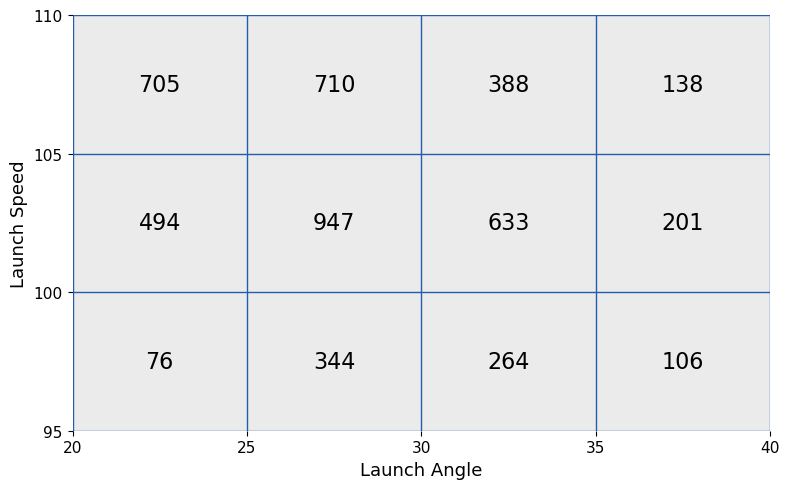

In [41]:
bin_plot(bins_2023, LA_breaks, LS_breaks, label_col='HR')

### 13.3.3 Plotting Measures over Bins

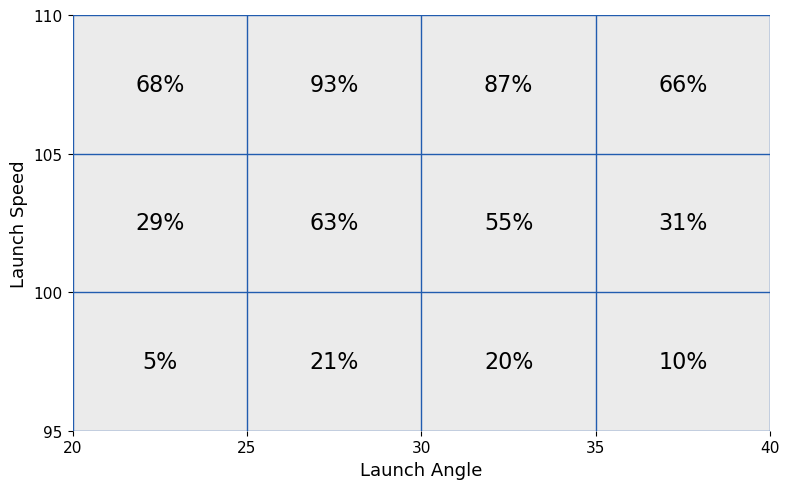

In [42]:
bin_plot(bins_2023, LA_breaks, LS_breaks, label_col='HR_Rate',
         label_fmt=lambda v: f'{round(v):.0f}%')

### 13.3.4 Changes in Batter Behavior

Logit difference in BIP rate per bin (2023 − 2021). Positive values mean 2023 batters hit more balls into that region.

In [43]:
def logit_rate(x, eps=0.01):
    x = np.clip(x, eps, 100 - eps)
    return np.log(x / (100 - x))

comparison = bins_2021_full.merge(bins_2023_full, on=['LA', 'LS'], suffixes=('_2021', '_2023'))
comparison['d_BIP_logits'] = logit_rate(comparison['BIP_Rate_2023']) - logit_rate(comparison['BIP_Rate_2021'])
comparison['d_HR_logits'] = logit_rate(comparison['HR_Rate_2023']) - logit_rate(comparison['HR_Rate_2021'])

comparison[['LA', 'LS', 'BIP_Rate_2021', 'BIP_Rate_2023', 'd_BIP_logits']].round(3)

,LA,LS,BIP_Rate_2021,BIP_Rate_2023,d_BIP_logits
0,"(20, 25]","(95, 100]",1.285,1.305,0.015
1,"(20, 25]","(100, 105]",1.372,1.389,0.013
2,"(20, 25]","(105, 110]",0.819,0.829,0.012
3,"(25, 30]","(95, 100]",1.264,1.324,0.047
4,"(25, 30]","(100, 105]",1.158,1.214,0.048
5,"(25, 30]","(105, 110]",0.602,0.613,0.018
6,"(30, 35]","(95, 100]",1.104,1.079,-0.023
7,"(30, 35]","(100, 105]",0.870,0.935,0.072
8,"(30, 35]","(105, 110]",0.362,0.357,-0.012
9,"(35, 40]","(95, 100]",0.812,0.873,0.073


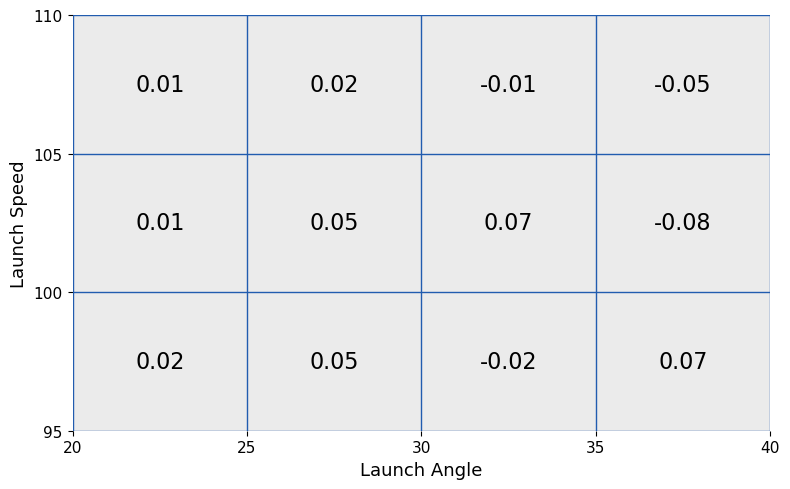

In [44]:
bin_plot(comparison, LA_breaks, LS_breaks, label_col='d_BIP_logits',
         label_fmt=lambda v: f'{v:.2f}')

### 13.3.5 Changes in Carry of the Baseball

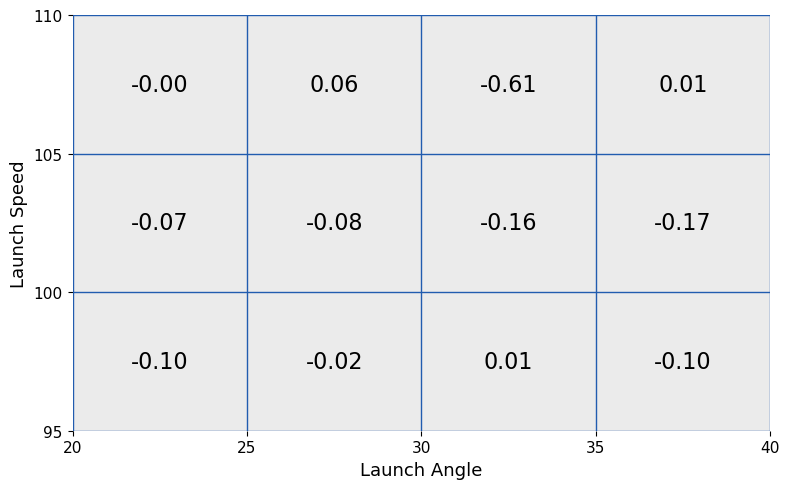

In [45]:
bin_plot(comparison, LA_breaks, LS_breaks, label_col='d_HR_logits',
         label_fmt=lambda v: f'{v:.2f}')

The overall HR rate stayed similar across seasons because 2023 hitters compensated by hitting the ball harder and at better angles, offsetting the reduced carry of the baseball.